In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier

In [10]:
df=pd.read_csv(r'dataset\predictive_maintenance.csv')


In [27]:

X = df.drop(columns=['Target', 'Failure Type', 'Product ID','UDI'])
y = df['Target']

In [28]:
X = X.rename(columns={
    'Air temperature [K]': 'Air_temperature_K',
    'Process temperature [K]': 'Process_temperature_K',
    'Rotational speed [rpm]': 'Rotational_speed_rpm',
    'Torque [Nm]': 'Torque_Nm',
    'Tool wear [min]': 'Tool_wear_min'
})

In [29]:
X['Temp_Diff'] = X['Process_temperature_K'] - X['Air_temperature_K']
X['Torque_Wear'] = X['Torque_Nm'] * X['Tool_wear_min']
X['Torque_RPM'] = X['Torque_Nm'] * X['Rotational_speed_rpm']

In [30]:
X = pd.get_dummies(X, columns=['Type'], drop_first=True)

In [31]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
scale_pos_weight

np.float64(28.49852507374631)

The dataset contains far fewer failure cases than healthy cases. We calculated scale_pos_weight as the ratio of negative to positive samples, approximately 28.5. This tells XGBoost to give greater importance to failure examples during training, improving its ability to detect rare machine failures."

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [33]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

I used XGBoost with 300 boosting trees. The maximum tree depth was set to 6 to balance complexity and generalization. A learning rate of 0.05 ensured gradual learning. To reduce overfitting, I used subsample and colsample_bytree values of 0.8. Since the dataset is highly imbalanced, I applied scale_pos_weight to emphasize failure cases. The model was trained using log loss as the evaluation metric and random_state=42 for reproducibility

In [34]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

In [35]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.85      0.82      0.84        68

    accuracy                           0.99      2000
   macro avg       0.92      0.91      0.92      2000
weighted avg       0.99      0.99      0.99      2000


ROC-AUC Score:
0.9855224698575082


<Axes: >

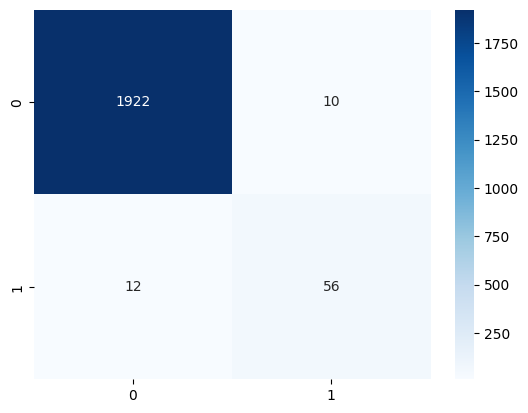

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cf=confusion_matrix(y_test, y_pred)
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')

<Figure size 1000x600 with 0 Axes>

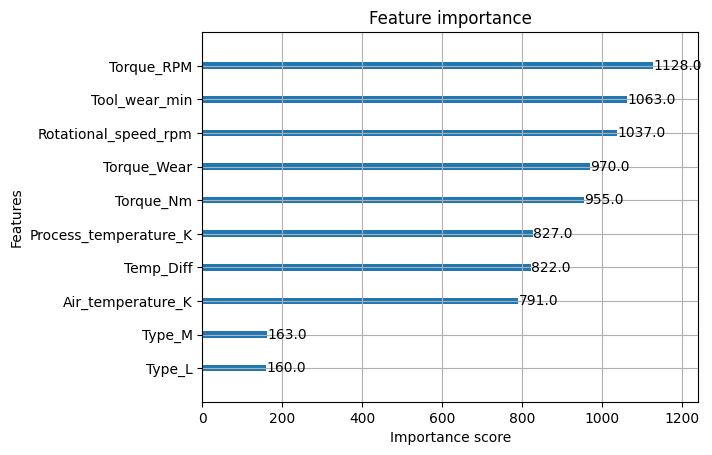

In [36]:
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(xgb, max_num_features=10)
plt.show()

In [37]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

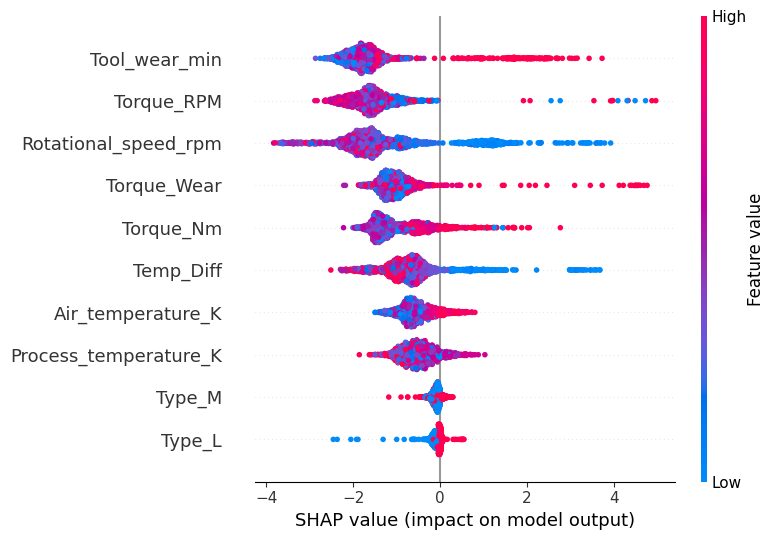

In [38]:
shap.summary_plot(shap_values, X_test)

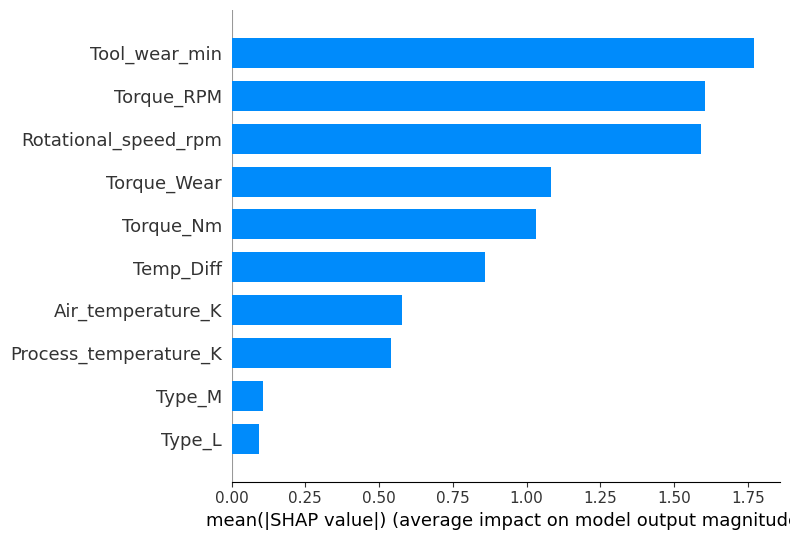

In [39]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [46]:
import joblib

joblib.dump(xgb, 'xgboost_model.pkl')
print("XGBoost model saved as 'xgboost_model.pkl'")

XGBoost model saved as 'xgboost_model.pkl'
